[ DATA ]
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   


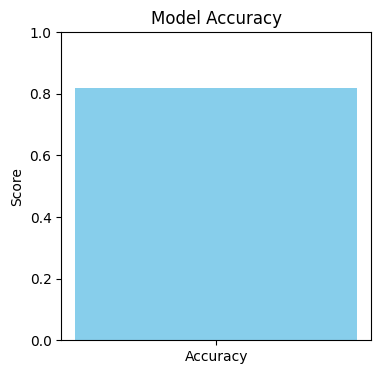

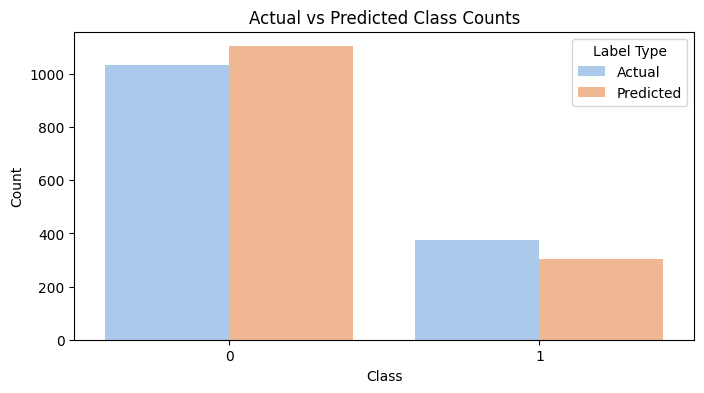

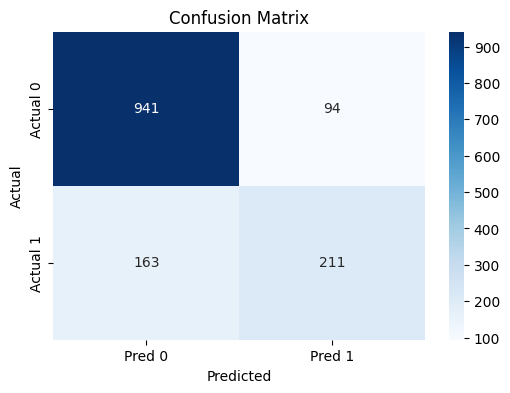

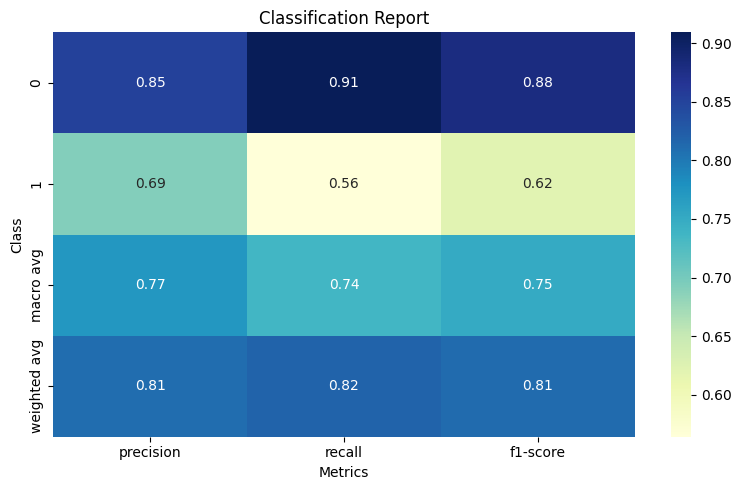

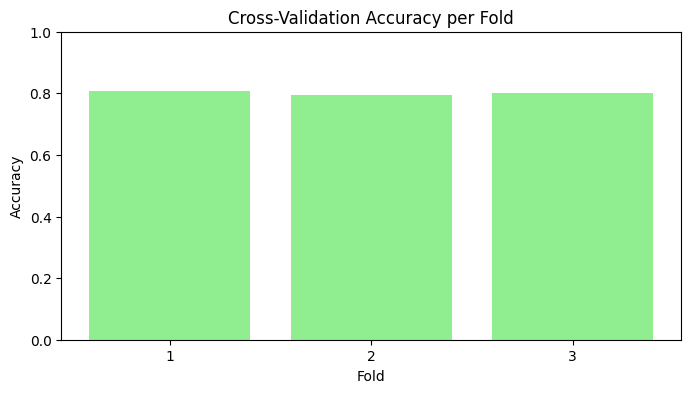

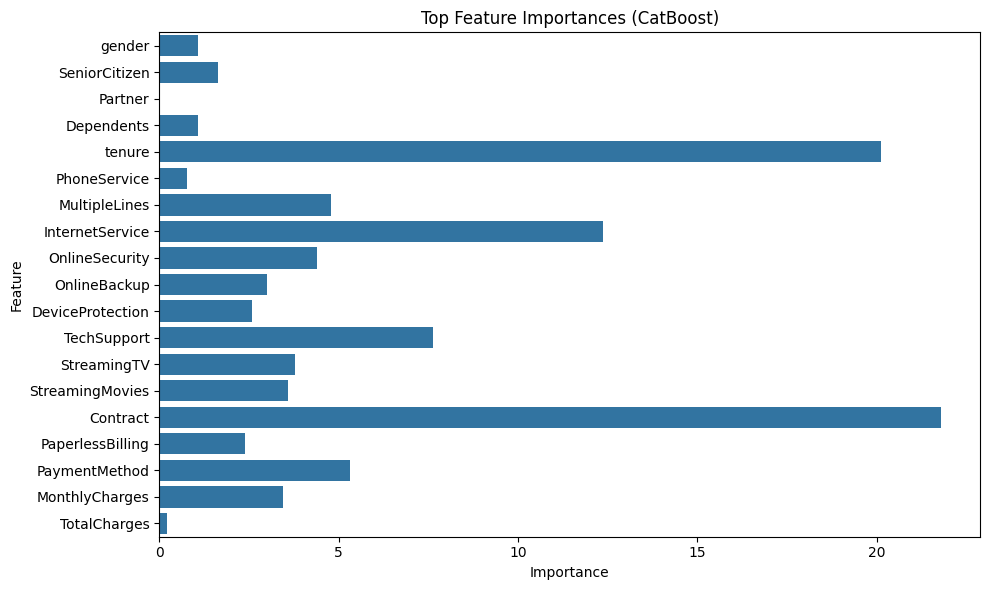

In [10]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from catboost import CatBoostClassifier

# load & prepare data
data = pd.read_csv('../../CSV/telco_customer_churn.csv')
print("[ DATA ]")
print(data)

# Define target
y = data['Churn'].map({'Yes': 1, 'No': 0})

# Drop target column + drop customerID if exists
X = data.drop(columns=['Churn'])
if 'customerID' in X.columns:
    X = X.drop(columns=['customerID'])
    
# Continue with split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

cat_cols = X.select_dtypes(include='object').columns.tolist()

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    verbose=0,
    random_seed=42
)
model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_test, y_test))

# test model by making predictions
# Get predicted probabilities
probs = model.predict_proba(X_test)[:, 1]

# Adjust threshold to reduce false negatives or false positives
threshold = 0.5 # tweak this to balance FP and FN
predictions = (probs > threshold).astype(int)

# evaluate model
accuracy = accuracy_score(y_test, predictions)

# save model
joblib.dump(model, 'models/customer_churn_predictor[CatBoost].joblib')

# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()


# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

# Convert to DataFrame (remove 'accuracy' to keep it 2D for heatmap)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot (Fix for CatBoost with object features)
X_encoded = X.copy()
for col in cat_cols:
    X_encoded[col] = X_encoded[col].astype(str)

cv_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    verbose=0,
    random_seed=42
)

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in cv.split(X_encoded, y):
    X_train_cv, X_val_cv = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    
    model_cv = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        verbose=0,
        random_seed=42
    )
    
    model_cv.fit(X_train_cv, y_train_cv, cat_features=cat_cols)
    preds = model_cv.predict(X_val_cv)
    acc = accuracy_score(y_val_cv, preds)
    scores.append(acc)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 4))
plt.show()

importances = model.get_feature_importance()
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Top Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()